# Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("blood_transfusion.csv")

# Task 1

## 1.1

In [4]:
df.head()

,months_since_last_donation,total_number_of_donations,total_blood_donated,months_since_first_donation,class
0,2.0,50.0,12500.0,98.0,1
1,0.0,13.0,3250.0,28.0,1
2,1.0,16.0,4000.0,35.0,1
3,2.0,20.0,5000.0,45.0,1
4,1.0,24.0,6000.0,77.0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_since_last_donation   748 non-null    float64
 1   total_number_of_donations    748 non-null    float64
 2   total_blood_donated          748 non-null    float64
 3   months_since_first_donation  748 non-null    float64
 4   class                        748 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 29.3 KB


In [9]:
df.describe().round(3)

,months_since_last_donation,total_number_of_donations,total_blood_donated,months_since_first_donation,class
count,748.000,748.000,748.000,748.000,748.000
mean,9.507,5.515,1378.676,34.282,0.238
std,8.095,5.839,1459.827,24.377,0.426
min,0.000,1.000,250.000,2.000,0.000
25%,2.750,2.000,500.000,16.000,0.000
50%,7.000,4.000,1000.000,28.000,0.000
75%,14.000,7.000,1750.000,50.000,0.000
max,74.000,50.000,12500.000,98.000,1.000


In [26]:
df.groupby("class").mean().round(3)

,months_since_last_donation,total_number_of_donations,total_blood_donated,months_since_first_donation
class,,,,
0,10.772,4.802,1200.439,34.770
1,5.455,7.798,1949.438,32.719


### one-minute story
Here, we compare the average donation history of people in class 0 and class 1. Class 1 represents donors who returned to donate again in the following month.
The clearest difference is in the time since the last donation. For class 1, it is only about 5.5 months, compared with 10.8 months for class 0. So, people who donated more recently were more likely to return.
We can also see that class 1 donors donated more frequently: about 7.8 times on average compared with 4.8 times for class 0. As a result, their total donated blood is also much higher, around 1,950 milliliters compared with 1,200.
Interestingly, the time since the first donation is quite similar between the two groups. This suggests that recent and frequent donation behavior may be more informative than simply how long someone has been a donor.

## Task 1.2

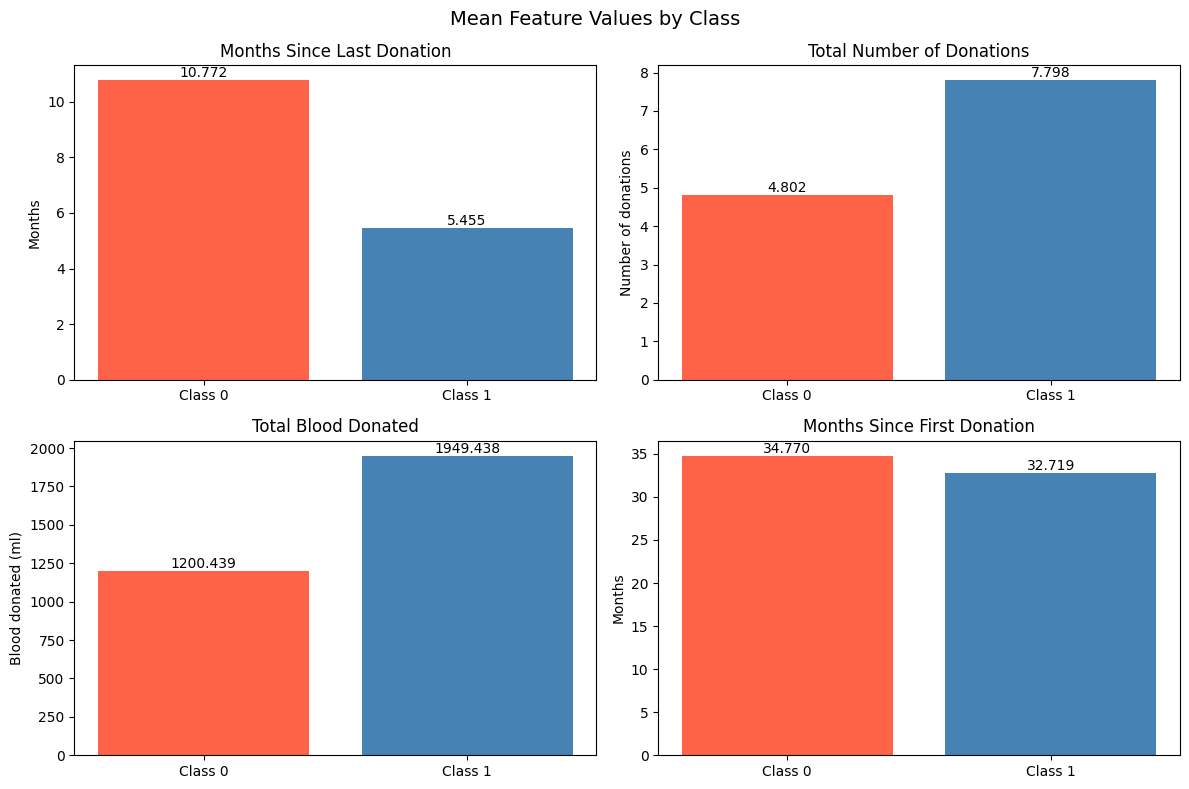

In [28]:
import matplotlib.pyplot as plt

means = df.groupby("class").mean()

features = [
    "months_since_last_donation",
    "total_number_of_donations",
    "total_blood_donated",
    "months_since_first_donation"
]

titles = [
    "Months Since Last Donation",
    "Total Number of Donations",
    "Total Blood Donated",
    "Months Since First Donation"
]

ylabels = [
    "Months",
    "Number of donations",
    "Blood donated (ml)",
    "Months"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    
    values = means[feature]
    
    bars = ax.bar(
        ["Class 0", "Class 1"],
        values,
        color=["tomato", "steelblue"]
    )
    
    ax.set_title(titles[i])
    ax.set_ylabel(ylabels[i])

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom"
        )

plt.suptitle("Mean Feature Values by Class", fontsize=14)
plt.tight_layout()
plt.show()

# Task 2. Preprocessing 


For this dataset, four predictors are already numeric, so we apply only standardization.

In [38]:
from sklearn.preprocessing import StandardScaler

def preprocessing(df):
    # Separate features and target variable
    X = df.drop(columns="class")
    y = df["class"]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    preprocessed_df = pd.DataFrame(X_scaled, columns=X.columns)
    preprocessed_df["class"] = y.values

    return preprocessed_df

In [32]:
preprocessed_df = preprocessing(df)
preprocessed_df.head()

,months_since_last_donation,total_number_of_donations,total_blood_donated,months_since_first_donation,class
0,-0.927899,7.623346,7.623346,2.615633,1
1,-1.175118,1.282738,1.282738,-0.257881,1
2,-1.051508,1.796842,1.796842,0.029471,1
3,-0.927899,2.482313,2.482313,0.439973,1
4,-1.051508,3.167784,3.167784,1.753579,0


# Task 3. Creating a train and test set

## Introduce two different split
* Split 1: 80% training, 20% testing
* Split 2: 60% training, 40% testing

## NOTE : Stratification based on `class`
`class` is imbalanced according to task 1 analysis, so without stratification, the random split could give one subset considerably more class 1 samples than another.

In [39]:
from sklearn.model_selection import train_test_split

# Split 1: 80% training, 20% testing
df_80_train, df_20_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["class"]
)
preprocessed_df_80 = preprocessing(df_80_train)
preprocessed_df_20_test = preprocessing(df_20_test)

# Split 2: 60% training, 40% testing
df_60_train, df_40_test = train_test_split(
    df,
    test_size=0.40,
    random_state=42,
    stratify=df["class"]
)
preprocessed_df_60 = preprocessing(df_60_train)
preprocessed_df_40_test = preprocessing(df_40_test)

# Task 4. Classification algorithms

## 4.1 KNN classifier